In [1]:
from pprint import pprint
import cirq_superstaq as css
import cirq
import warnings
import sys
sys.path.append('../')
import resource_estimation as res
from scripts.cultivate_json import GATE2STR
import scripts.layout_figures as lfs

category_colors = {
    "None": "#ffffff",
    "T Factory": "#4ddef1",
    "S Factory": "#fcc084",
    "Data Qubit": "#a4f0c2",
    "Ancilla Patch": "#f5bad6",
    "Distillation": "#E6E6FA",
    "CNOT": "#ed6340"
}

In [2]:
circuit = cirq.testing.random_circuit(10, 10, 1, random_state=19, gate_domain={cirq.H: 1, cirq.S: 1, cirq.CNOT: 2, cirq.T: 1})
circuit

┌──┐   ┌──┐   ┌──┐   ┌──┐   ┌────┐   ┌───┐   ┌──┐   ┌──┐
0: ───H───@────H──────S───────@─────@─────────X───────X─────H──────T─────
          │                   │     │         │       │
1: ───H───X────S──────H──────H┼─────┼H─────H──┼─────H─┼─────────────X────
                              │     │         │       │             │
2: ───T───H─────X──────X─────@┼─────┼T──────X─┼─────@─┼─────H──────H┼────
                │      │     ││     │       │ │     │ │             │
3: ───T───H────H┼─────T┼─────┼X─────X───────┼X┼─────┼T┼─────T──────X┼────
                │      │     │              │││     │ │            ││
4: ───H───S────S┼─────T┼─────┼@─────@──────T┼┼┼─────┼─@─────T──────┼┼────
                │      │     ││     │       │││     │              ││
5: ───H─────────@─────H┼─────X┼─────┼T──────┼┼┼─────X───────H──────@┼────
                       │      │     │       │││                     │
6: ───H───S────T──────H┼─────T┼─────X───────┼┼@─────H───────X──────H┼────
                       │      │             ││              │       │
7: ───T───T────T──────T┼─────T┼─────S───────@┼──────S───────┼T─────T┼────
                       │      │              │              │       │
8: ───@───H────T───────@──────X──────────────@──────H───────@──────H┼────
      │                                                             │
9: ───X───T──────────────────H──────H──────S────────────────H───────@────
              └──┘   └──┘   └──┘   └──┘   └────┘   └───┘   └──┘   └──┘

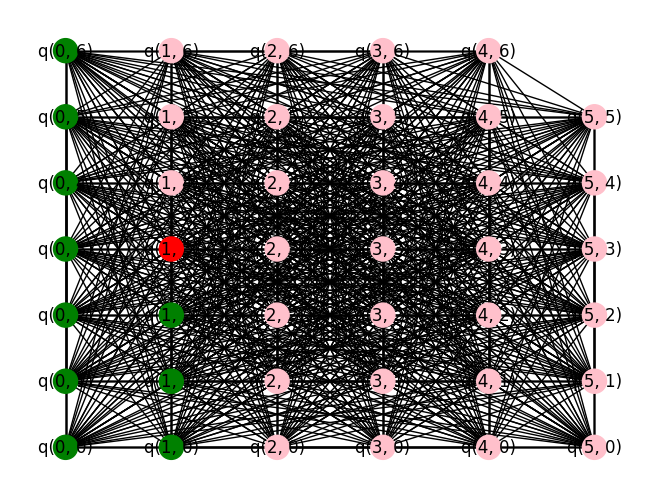

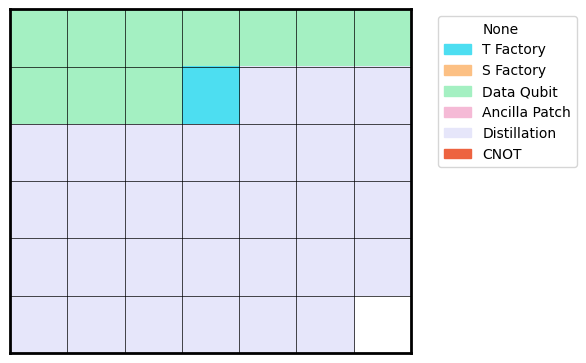

In [3]:
lyt = res.layout.MovementDistillery(input_circuit=circuit, num_t_factories=1)
lyt.draw()
fig, ax, im = lfs.plot_layout(lyt, category_colors=category_colors, transpose=False)

In [4]:
arc = res.architecture.DefaultMovement()
compiled_circuit = res.compile_ftqc.ft_compile(layout=lyt, arc=arc)
compiled_circuit

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 75/75 [00:00<00:00, 195265.55it/s]


┌──┐
(0, 0): ───SE(1)───H───────────────────────SE(1)───MOVE_IZ───@───MOVE_IZ───SE(1)───H───────────────────────────SE(1)───S───SE(1)───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────MOVE_IZ───@───MOVE_IZ───SE(1)───MOVE_IZ───@───MOVE_IZ───SE(1)───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────MOVE_IZ───X───MOVE_IZ───SE(1)────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────MOVE_IZ───X───MOVE_IZ───SE(1)───H────────SE(1)────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────MOVE_IZ───X───MOVE_IZ───SE(1)───S───────────────────────────SE(1)───────
                                                             │                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       │                               │                                                                                                                                                                                                                               │                                                                                                                                                                                                                                                                                                                                │                                             

In [5]:
res.estimate.ResourceEstimator(arc=arc).serial_circuit_cost(compiled_circuit)

{cirq.ops.measurement_gate.MeasurementGate: 214522,
 cirq.CZ: 734645,
 cirq.ops.common_channels.ResetChannel: 235862,
 cirq.ops.phased_x_z_gate.PhasedXZGate: 453016,
 cirq.ops.permutation_gate.QubitPermutationGate: 86968}